# Final Project Phase 3 Summary
This Jupyter Notebook (.ipynb) will serve as the skeleton file for your submission for Phase 3 of the Final Project. Complete all sections below as specified in the instructions for the project, covering all necessary details. We will use this to grade your individual code (Do this whether you are in a group or not). Good luck! <br><br>

Note: To edit a Markdown cell, double-click on its text.

## Jupyter Notebook Quick Tips
Here are some quick formatting tips to get you started with Jupyter Notebooks. This is by no means exhaustive, and there are plenty of articles to highlight other things that can be done. We recommend using HTML syntax for Markdown but there is also Markdown syntax that is more streamlined and might be preferable. 
<a href = "https://towardsdatascience.com/markdown-cells-jupyter-notebook-d3bea8416671">Here's an article</a> that goes into more detail. (Double-click on cell to see syntax)

# Heading 1
## Heading 2
### Heading 3
#### Heading 4
<br>
<b>BoldText</b> or <i>ItalicText</i>
<br> <br>
Math Formulas: $x^2 + y^2 = 1$
<br> <br>
Line Breaks are done using br enclosed in < >.
<br><br>
Hyperlinks are done with: <a> https://www.google.com </a> or 
<a href="http://www.google.com">Google</a><br>

# Video Presentation

If you uploaded your Video Presentation to Bluejeans, YouTube, or any other streaming services, please provide the link here:


*   Video Presentation Link


Make sure the video sharing permissions are accessible for anyone with the provided link.

In [61]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import requests
import json
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from datetime import datetime
from bs4 import BeautifulSoup as bs4

# set display options so we can see all cols when printing dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# URLs, Paths & API Keys:

CPI_URL = "https://fred.stlouisfed.org/data/CPIAUCSL"
EIA_BASE_URL = "https://api.eia.gov/v2/petroleum/pri/spt/data/"
EIA_API_KEY = "gc3m0emd44qaMHTNQxwmLqupbzdCtHHB2G6aOCNl"
oil_export_path = "eia_wti_quarterly.csv"
raw_cpi_export_path = "cpi_raw.csv"
clean_cpi_export_path = "cpi_clean.csv"
baggage_path = 'BaggageFees.xlsx'


pd.set_option('future.no_silent_downcasting', True) # this is to silence errors I was getting with pandas versions 

# Note: you can also change base year explicitly in the CPI function with optional paramter base_year (default = 2025)

# Data Collection and Cleaning


Transfer/update the data collection and cleaning you created for Phase II below. You may include additional cleaning functions if you have extra datasets. If no changes are necessary, simply copy and paste your phase II parsing/cleaning functions.


## Downloaded Dataset Requirement



In [63]:
airfares = pd.read_csv("ConsumerAirfares.csv")

# Drops columns that are duplicates or unnecessary
airfares = airfares.drop(["table_1_flag","Geocoded_City1","Geocoded_City2","Geocoded_City1 (city)","Geocoded_City2 (city)"],axis=1)

### Inconsistency: Fill necessary columns with missing values that have NaN values with 0
airfares["lf_ms"] = airfares["lf_ms"].fillna(0)
airfares["carrier_low"] = airfares["carrier_low"].fillna(0)
airfares["fare_low"] = airfares["fare_low"].fillna(0)
airfares = airfares.dropna(axis=1)

### Inconsistency: citymarketid_1 was a object with commas whereas citymarketid_2 was a column of ints, changed citymarketid_1 to be column of ints
airfares["citymarketid_1"] = airfares["citymarketid_1"].str.replace(',','').astype(int)

### Somewhat inconsistencies: changed passengers, fare, fare_large, fare_low to be integers or floats rounded to two decimal points to make calculations easier in the future
airfares["passengers"] = airfares["passengers"].astype(str).str.replace(',', '').astype(int)
airfares["fare"] = round(airfares["fare"].astype(str).str.replace('$','').astype(float),2)
airfares["fare_lg"] = round(airfares["fare_lg"].astype(str).str.replace('$','').astype(float),2)
airfares["fare_low"] = round(airfares["fare_low"].astype(str).str.replace('$','').astype(float),2)

airfares

,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,nsmiles,passengers,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low
0,2025,2,32467,31703,"Miami, FL (Metropolitan Area)","New York City, NY (Metropolitan Area)",1118,17955,208.52,B6,0.2551,191.48,B6,0.2551,191.48
1,2025,2,32575,32457,"Los Angeles, CA (Metropolitan Area)","San Francisco, CA (Metropolitan Area)",372,17310,157.68,WN,0.5006,169.03,AS,0.1193,140.59
2,2025,2,32575,31703,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",2510,13648,430.38,DL,0.2535,526.21,B6,0.2272,365.63
3,2025,2,31703,31454,"New York City, NY (Metropolitan Area)","Orlando, FL",989,12627,186.50,B6,0.3735,186.10,B6,0.3735,186.10
4,2025,2,30977,31703,"Chicago, IL","New York City, NY (Metropolitan Area)",773,11284,221.33,UA,0.4328,238.62,AA,0.2426,217.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118030,1996,1,33495,31454,"New Orleans, LA","Orlando, FL",550,111,138.88,DL,0.2600,174.49,NW,0.1400,112.40
118031,1996,1,30647,31995,"Cleveland, OH (Metropolitan Area)","Greensboro/High Point, NC",381,111,199.92,CO,0.8400,193.76,CO,0.8400,193.76
118032,1996,1,30158,31454,"Atlantic City, NJ","Orlando, FL",852,111,95.23,NK,0.9300,91.49,NK,0.9300,91.49
118033,1996,1,33244,33495,"Memphis, TN","New Orleans, LA",349,110,201.52,NW,0.8800,204.78,J7,0.0400,121.56


# Additional Dataset: 

In [64]:
def row_contains_keyword(row, keywords):
    #Check if a row contains keywords, which are likely column names.
    vals = [("" if pd.isna(v) else str(v).strip().lower()) for v in row.values]
    return any(word.lower() in v for v in vals for word in keywords)

def find_header_row(df):
    #Finds the row number that's probably the header
    keywords = ['rank', 'airline', '1Q', '2Q', '3Q', '4Q']
    for i, row in df.iterrows():
        if row_contains_keyword(row, keywords):
            non_empty = sum(1 for v in row.values if not pd.isna(v) and str(v).strip() != '')
            if non_empty >= 2:
                return i
    return None

def clean_dataframe(df):
    # Strip column names
    df.columns = [("" if pd.isna(x) else str(x).strip()) for x in df.columns]

    # Remove empty columns
    df = df.dropna(axis=1, how='all')

    # Find airline column
    key_col = None
    for col in df.columns:
        if 'airline' in str(col).strip().lower():
            key_col = col
            break

    # Remove rows with empty airline column
    if key_col:
        df = df[df[key_col].notna()]
        df.reset_index(drop=True, inplace=True)

    return df

# Dictionary to store all cleaned DataFrames
all_sheets = {}

baggage = pd.ExcelFile(baggage_path)

# Filter sheets from 2007 to 2025
sheets = [s for s in baggage.sheet_names if re.match(r'^(2007|2008|2009|201\d|202[0-5])$', s)]

for sheet_name in sheets:
    # Read to get row that's probably header
    df = pd.read_excel(baggage, sheet_name=sheet_name, header=None, dtype=object)
    
    header_row = find_header_row(df)
    
    # Now look at it now we know the header
    df = pd.read_excel(baggage, sheet_name=sheet_name, header=header_row, dtype=object)
    
    df = clean_dataframe(df)
    
    all_sheets[sheet_name] = df
    print(sheet_name)
    print(df.head(), "\n")


for sheet_name in all_sheets:
    if(sheet_name == '2025'):
        break;
    df = all_sheets[sheet_name]
    df = df.dropna() 
    all_sheets[sheet_name] = df.reset_index(drop=True)

for sheet_name in all_sheets: 
    all_sheets[sheet_name].drop('Rank', axis=1, errors='ignore', inplace=True)
    print(sheet_name)
    print(all_sheets[sheet_name])

for sheet_name, df in all_sheets.items():
    cols = [col for col in df.columns if str(col).strip().upper() in ['1Q', '2Q', '3Q', '4Q','Full Year']]
    
    for col in cols:
        df[col] = df[col].replace(['-', None], 0).astype(float)


for sheet_name in sheets:
    print(sheet_name)
    print(all_sheets[sheet_name].head())

############ Function Call ############


2007
  Rank               Airline     1Q     2Q     3Q     4Q Full Year
0    1   American Airlines    28829  30015  31346  34348    124538
1    2     Delta Air Lines    20343  22447  25035  28721     96546
2    3       United Airlines  12045  13410  14829  12718     53002
3    4  Continental Airlines  10715  11045  10565  10519     42844
4    5  Northwest Airlines     8339   8956   9897  10309     37501 

2008
  Rank               Airline     1Q     2Q     3Q      4Q Full Year
0    1   American Airlines    32959  37101  94075  113856    277991
1    2         US Airways      7478  17917  67928   93759    187082
2    3     Delta Air Lines    26571  42461  47489   60542    177063
3    4       United Airlines  12219  19721  42283   58771    132994
4    5  Northwest Airlines     9641  15685  32695   63578    121599 

2009
  Rank               Airline      1Q      2Q      3Q      4Q Full Year
0    1     Delta Air Lines    102838  118356  129465  131060    481719
1    2   American Airlines   

## Web Collection Requirement \#1


In [65]:
# Note: Pylance errors because the skeleton template puts the helper functions below this block, so make sure to run those before this.

# HTML notes: th holds date, td holds value
def get_quarterly_cpi(raw_path=raw_cpi_export_path,clean_path=clean_cpi_export_path,data_url=CPI_URL,base_year=2025,silence=False):
    html = requests.get(data_url).text
    soup = bs4(html, "html.parser")
    table = soup.find("table", id="data-table-observations")
    if not table: # for debugging
        raise ValueError("CPI table not found; check HTML structure")

    rows = []
    tbody = table.find("tbody")
    for tr in tbody.find_all("tr"):
        th = tr.find("th")
        tds = tr.find_all("td")
        if not th or not tds:
            continue # skip irrelavant elements
        rows.append((th.get_text().strip(), tds[0].get_text().strip()))

    cpi = pd.DataFrame(rows, columns=["date","value"])
    cpi["date"]  = pd.to_datetime(cpi["date"])
    cpi["value"] = pd.to_numeric(cpi["value"])
    cpi = cpi.dropna().sort_values("date").reset_index(drop=True) # dropna not really needed but I figured it would make it semi future proof
    
    if silence != False:
        save_csv(cpi,raw_path,silence=silence) # store raw data w/ no "Rewrote..." message for nesting in another function
    else:
        save_csv(cpi, raw_path) # store raw data with explicit rewrite message (default silence=False)

    cpi["qstart"] = cpi["date"].dt.to_period("Q").dt.start_time
    cpi_q = (cpi.groupby("qstart",as_index=False)["value"]
               .mean()
               .rename(columns={"qstart":"quarter_start_date","value":"cpi_index"}))
    cpi_q["quarter"] = cpi_q["quarter_start_date"].apply(to_quarter_label)

    q = cpi_q["quarter"].astype(str)
    m = q.str.startswith(str(base_year))
    base = cpi_q[m].iloc[-1] if m.any() else cpi_q.iloc[-1]

    # using .copy() to start clean, not technically needed though. Also good for splitting nom vs real $.
    out = cpi_q[["quarter","cpi_index"]].copy()
    out["cpi_base_year"] = base_year
    out["cpi_base_value"] = float(base["cpi_index"])
    out["cpi_base_quarter_used"] = str(base["quarter"])

    if silence != False:
        save_csv(out, clean_path,silence=silence) # store raw data w/ no "Rewrote..." message for nesting in another function
    else:
        save_csv(out, clean_path) # store clean data

    return out


############ Function Call ############
get_quarterly_cpi()


rewrote cpi_raw.csv
rewrote cpi_clean.csv


,quarter,cpi_index,cpi_base_year,cpi_base_value,cpi_base_quarter_used
0,1947Q1,21.700000,2025,323.288,2025Q3
1,1947Q2,22.010000,2025,323.288,2025Q3
2,1947Q3,22.490000,2025,323.288,2025Q3
3,1947Q4,23.126667,2025,323.288,2025Q3
4,1948Q1,23.616667,2025,323.288,2025Q3
...,...,...,...,...,...
310,2024Q3,314.182667,2025,323.288,2025Q3
311,2024Q4,316.538667,2025,323.288,2025Q3
312,2025Q1,319.492000,2025,323.288,2025Q3
313,2025Q2,320.800333,2025,323.288,2025Q3


## Web Collection Requirement #2

In [66]:
# CPI must successfully run before this one as CPI is used for initial normalization to adjust for inflation (use 2025 $; base year in cpi function)
# Note: Same Pylance errors as CPI due to skeleton template code block placement

# Note: Columns are ['period', 'duoarea', 'area-name', 'product', 'product-name', 'process', 'process-name', 'series', 'series-description', 'value', 'units']
# Note: nested get_quarterly_cpi() call to ensure CPI data is fresh each time this function is run. They can be run seperately though (set cpi_df=cpi_df)

def get_eia_data(cpi_df=get_quarterly_cpi(silence=True), base=EIA_BASE_URL, api_key=EIA_API_KEY,export_path=oil_export_path):
    params = {
        "api_key": api_key,
        "frequency": "monthly", # quartlery not available so this is one of the inconsistencies
        "data[0]": "value", # name of key metric in API so have to set it explicitly
        "length": 5000,  # need to expand page size because data runs long
        "start": "2000-01-01" # can change in Phase III based on what data bottlenecks on dates
    }
    r = requests.get(base, params=params)
    parsed = json.loads(r.text)

    rows = []
    if isinstance(parsed, dict): # checks object is a dict format, throws error print message if format changes
        rows = parsed["response"]["data"]

    eia = pd.DataFrame(rows)

    if eia.empty:
        return "Not working, data is empty." # debug if data is empty

    eia = eia[eia["series"].eq("RWTC")] # mask Boolean indexing to get only WTI spot prices
    # Note: RWTC is the specific WTI provided spot price name that seems to be best for aviation purposes based on what we researched


    eia["period"] = pd.to_datetime(eia["period"])
    eia["value"] = pd.to_numeric(eia.get("value", np.nan))
    eia = eia.dropna(subset=["period", "value"]) # drops any rows with NaN in period or value, but we didn't see any

    # monthly -> quarterly mean
    eia["qstart"] = eia["period"].dt.to_period("Q").dt.start_time
    wti_q = (
        eia.groupby("qstart", as_index=False)["value"]
           .mean()
           .rename(columns={"qstart": "quarter_start_date", "value": "wti_usd_nominal"})
    )
    wti_q["quarter"] = wti_q["quarter_start_date"].apply(to_quarter_label)

    # inflation adjust with CPI already built
    cpi_small = cpi_df[["quarter", "cpi_index", "cpi_base_value"]].copy()
    merged = wti_q.merge(cpi_small, on="quarter", how="left")
    
    # Math is based on base year (from CPI function call)
    merged["wti_usd_real"] = merged["wti_usd_nominal"] * (merged["cpi_base_value"] / merged["cpi_index"])

    eia_clean = merged[["quarter", "wti_usd_nominal", "wti_usd_real"]].sort_values("quarter").reset_index(drop=True)
    save_csv(eia_clean, export_path) # store inflation-adjusted oil price data
    return eia_clean

############ Function Call ############
get_eia_data()

rewrote eia_wti_quarterly.csv


,quarter,wti_usd_nominal,wti_usd_real
0,2000Q1,28.823333,54.780939
1,2000Q2,28.776667,54.266873
2,2000Q3,31.613333,59.076366
3,2000Q4,31.990000,59.357087
4,2001Q1,28.816667,52.962379
...,...,...,...
99,2024Q4,70.686667,72.193869
100,2025Q1,71.836667,72.690184
101,2025Q2,64.626667,65.127818
102,2025Q3,65.736667,65.736667


# Additional Functions

In [67]:
# formatting dates, need to use universally
# date format: YYYYQn (e.g. 2023Q1, 2025Q2)
def to_quarter_label(ts):
    q = ((ts.month - 1) // 3) + 1 # map month to Q when divide by 3, but add 1 to make Q0 Q1
    return f"{ts.year}Q{q}"

# save dataframe to csv with an explicit mention of the path
def save_csv(df, path, silence=False):
    df.to_csv(path, index=False)
    if silence != True:
        print(f"rewrote {path}") # to help debugging

    
############ Function Call ############
# for to_quarter_label, single and pandas examples:
print(to_quarter_label(datetime(2025, 2, 15)))
dates = pd.to_datetime(["2024-01-10", "2024-05-20", "2024-12-31"])
print(dates.map(to_quarter_label).tolist())

# no test for csv function call but ->
# Note: We added the CSV silence feature to better our debugging and minimize unnecessary messages being printed on function calls when we nested the CPI function in the EIA function

2025Q1
['2024Q1', '2024Q2', '2024Q4']


# Merging datasets additional cleaning for analysis

In [68]:
# load cleaned datasets from Phase II
cpi_df = pd.read_csv("cpi_clean.csv")
oil_df = pd.read_csv("eia_clean.csv")

print(f"CPI: {cpi_df.shape[0]} quarters")
print(f"Oil: {oil_df.shape[0]} quarters")
print("\nCPI cols:", list(cpi_df.columns))
print("Oil cols:", list(oil_df.columns))

# gonna merge CPI and oil data...both should have 'quarter' col
base_df = cpi_df.merge(oil_df, on='quarter')
print(f"Merged dataset: {base_df.shape[0]} quarters")
print("Columns:", list(base_df.columns))

# helper function for making quarter labels
def to_quarter_label(ts):
    q = ((ts.month - 1) // 3) + 1
    return f"{ts.year}Q{q}"

# Step 3: Build quarterly airfare dataset from raw consumer airfare data
print("=== Building Quarterly Airfare Dataset ===")

# load raw airfare data (already cleaned in Phase II)
airfare = pd.read_csv("ConsumerAirfares.csv")
print(f"Loaded airfare data: {airfare.shape}")

# make quarter col in format YYYYQN
airfare['quarter'] = airfare['Year'].astype(str) + 'Q' + airfare['quarter'].astype(str)

# need to clean the $ and commas from passengers/fare cols
# (we did this in Phase II but re-applying just to be safe)
airfare['passengers'] = airfare['passengers'].astype(str).str.replace(',', '').astype(int)
airfare['fare'] = airfare['fare'].astype(str).str.replace('$', '').astype(float)

# calc weighted avg fare by quarter
# weight by passengers bc bigger routes should count more (more accurate avg)
airfare_q = airfare.groupby('quarter').apply(
    lambda x: pd.Series({
        'avg_domestic_fare': (x['fare'] * x['passengers']).sum() / x['passengers'].sum(),
        'total_passengers': x['passengers'].sum()
    })
).reset_index()

print(f"Quarterly airfare dataset created: {airfare_q.shape}")
print(airfare_q.head())

# Step 4: Build quarterly baggage fee dataset
print("\n=== Building Quarterly Baggage Fee Dataset ===")

# helper functions from BaggageCleaner approach
def row_contains_keyword(row, keywords):
    vals = [("" if pd.isna(v) else str(v).strip().lower()) for v in row.values]
    return any(word.lower() in v for v in vals for word in keywords)

def find_header_row(df):
    keywords = ['rank', 'airline', '1q', '2q', '3q', '4q']
    for i, row in df.iterrows():
        if row_contains_keyword(row, keywords):
            non_empty = sum(1 for v in row.values if not pd.isna(v) and str(v).strip() != '')
            if non_empty >= 2:
                return i
    return None

# load excel w/ baggage data
baggage_file = pd.ExcelFile('BaggageFees.xlsx')

# get sheets for years 2007-2025
year_sheets = [s for s in baggage_file.sheet_names if re.match(r'^(200\d|201\d|202[0-5])$', s)]

# gonna store all the quarterly baggage data here
baggage_rows = []

# process each year sheet (each sheet = 1 year)
for year in year_sheets:
    # read to find header row
    df = pd.read_excel(baggage_file, sheet_name=year, header=None, dtype=object)
    header_row = find_header_row(df)
    
    if header_row is None:
        continue
    
    # re-read with correct header
    df = pd.read_excel(baggage_file, sheet_name=year, header=header_row, dtype=object)
    df.columns = [("" if pd.isna(x) else str(x).strip()) for x in df.columns]
    
    # find airline col
    airline_col = None
    for col in df.columns:
        if 'airline' in col.lower():
            airline_col = col
            break
    
    # if no airline col, use second col (after Rank)
    if airline_col is None and len(df.columns) > 1:
        airline_col = df.columns[1]
    
    if airline_col is None:
        continue
    
    # get quarterly cols
    q_cols = [c for c in df.columns if str(c).strip().upper() in ['1Q', '2Q', '3Q', '4Q']]
    
    if not q_cols:
        continue
    
    # process each row
    for idx, row in df.iterrows():
        airline = row[airline_col]
        if pd.isna(airline) or str(airline).strip() == '':
            continue
        
        for q_col in q_cols:
            val = row[q_col]
            # clean the value
            if pd.isna(val) or val == '-':
                val = 0
            else:
                try:
                    val = float(str(val).replace(',', ''))
                except:
                    val = 0
            
            # map 1Q -> Q1, etc
            q_num = q_col.strip()[0]  # gets the '1' from '1Q'
            quarter = f"{year}Q{q_num}"
            
            baggage_rows.append({
                'quarter': quarter,
                'airline': str(airline).strip(),
                'baggage_fees': val
            })

print(f"Collected {len(baggage_rows)} baggage fee records")

# make df from all rows
baggage_long = pd.DataFrame(baggage_rows)

# aggregate by quarter (sum across all airlines)
baggage_q = baggage_long.groupby('quarter')['baggage_fees'].sum().reset_index()
baggage_q.columns = ['quarter', 'total_baggage_fees']

print(f"Quarterly baggage dataset created: {baggage_q.shape}")
print(baggage_q.head())
print(baggage_q.tail())

CPI: 315 quarters
Oil: 103 quarters

CPI cols: ['quarter', 'cpi_index', 'cpi_base_year', 'cpi_base_value', 'cpi_base_quarter_used']
Oil cols: ['quarter', 'wti_usd_nominal', 'wti_usd_real_2025']
Merged dataset: 103 quarters
Columns: ['quarter', 'cpi_index', 'cpi_base_year', 'cpi_base_value', 'cpi_base_quarter_used', 'wti_usd_nominal', 'wti_usd_real_2025']
=== Building Quarterly Airfare Dataset ===
Loaded airfare data: (118035, 26)
Quarterly airfare dataset created: (118, 3)
  quarter  avg_domestic_fare  total_passengers
0  1996Q1         167.701099          543095.0
1  1996Q2         163.403300          627355.0
2  1996Q3         162.707545          608064.0
3  1996Q4         165.281679          615511.0
4  1997Q1         168.791953          603333.0

=== Building Quarterly Baggage Fee Dataset ===


/var/folders/g1/jllm_9y97l9_5s8914spvntm0000gn/T/ipykernel_4298/2647447514.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  airfare_q = airfare.groupby('quarter').apply(


Collected 1304 baggage fee records
Quarterly baggage dataset created: (76, 2)
  quarter  total_baggage_fees
0  2007Q1            209363.0
1  2007Q2            226029.0
2  2007Q3            244832.0
3  2007Q4            248347.0
4  2008Q1            245129.0
   quarter  total_baggage_fees
71  2024Q4         3476006.548
72  2025Q1         3290196.198
73  2025Q2         3613258.528
74  2025Q3               0.000
75  2025Q4               0.000


## Data Sources

Include sources (as links) to your datasets. If any of these are different from your sources used in Phase II, please <b>clearly</b> specify.

*   Downloaded Dataset Source:
*   Web Collection #1 Source:
*   Web Collection #2 Source:



# Data Analysis
For the Data Analysis section, you are required to utilize your data to complete the following:

*   Create at least 5 insights
*   Generate at least 3 data visualizations

Create a function for each of the following sections mentioned above. Do not forget to fill out the explanation section for each function. 

Make sure your data analysis is not too simple. Performing complex aggregation and using modules not taught in class shows effort, which will increase the chance of receiving full credit. 

# Topic Summary

This project analyzes the relationship between real airfare costs and real baggage revenue. We utilized data collected about airfares and baggage fees from the BTS (Bureau of Transportation Statistics), oil prices from the U.S. Energy Information Administration, and CPI data from the Federal Reserve (CPI). We get this data from 2010 to 2025 into one dataset with inflation, oil price, baggage fee, and airfare data to find trends in the data. The primary objective was to determine the economic drivers behind airfare pricing and ancillary revenue growth. Using Linear and Polynomial Regression, alongside a Random Forest Regressor for feature importance, we analyzed the impact of fuel costs (WTI Oil Price), passenger demand, and non-fare revenue on average ticket price. 

## Insights

In [69]:
# Insight 1: Oil vs Airfare Prediction using Linear Regression
print("=== Insight 1: Predicting Airfare from Oil Prices (sklearn) ===")

# prepare data for sklearn - need to reshape for model
X = dataset_a[['wti_real_2025']].values  # features (oil price)
y = dataset_a['avg_domestic_fare'].values  # target (airfare)

# create and train linear regression model
model = LinearRegression()
model.fit(X, y)

# make predictions
y_pred = model.predict(X)

# evaluate model
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Linear Regression Results:")
print(f"  Coefficient (slope): {model.coef_[0]:.4f}")
print(f"  Intercept: {model.intercept_:.2f}")
print(f"  R² score: {r2:.4f}")
print(f"  RMSE: ${rmse:.2f}")

# test prediction: what fare for $100 oil?
test_oil = np.array([[100]])
predicted_fare = model.predict(test_oil)[0]
print(f"\nPrediction: At $100/barrel oil, avg domestic fare = ${predicted_fare:.2f}")

# find periods of high vs low oil
high_oil = dataset_a[dataset_a['wti_real_2025'] > dataset_a['wti_real_2025'].median()]
low_oil = dataset_a[dataset_a['wti_real_2025'] <= dataset_a['wti_real_2025'].median()]

print(f"\nAvg fare during high oil periods: ${high_oil['avg_domestic_fare'].mean():.2f}")
print(f"Avg fare during low oil periods: ${low_oil['avg_domestic_fare'].mean():.2f}")
print(f"Difference: ${high_oil['avg_domestic_fare'].mean() - low_oil['avg_domestic_fare'].mean():.2f}")

print("\nInsight: Strong positive relationship - for every $1 increase in oil,")
print(f"airfares increase by ${model.coef_[0]:.2f}. Model explains {r2*100:.1f}% of fare variation.")

=== Insight 1: Predicting Airfare from Oil Prices (sklearn) ===
Linear Regression Results:
  Coefficient (slope): 0.0821
  Intercept: 200.98
  R² score: 0.0174
  RMSE: $18.46

Prediction: At $100/barrel oil, avg domestic fare = $209.19

Avg fare during high oil periods: $209.85
Avg fare during low oil periods: $207.23
Difference: $2.62

Insight: Strong positive relationship - for every $1 increase in oil,
airfares increase by $0.08. Model explains 1.7% of fare variation.


### Insight 1 Explanation

This function utilizes a Linear Regression model to predict average domestic airfares based on real WTI oil prices. The output reveals a positive coefficient of 0.08, meaning for every 1 dollar increase in oil prices, airfares generally rise by 8 cents. However, the low $R^2$ score (0.017) indicates that oil prices don't predict airfares well. This is very significant since it implies that oil prices may not translate to increased customer airfares and other factors like demand, seasonality, or competition may be more important.

In [88]:
# Insight 2: baggage revenue vs oil (polynomial regression)
print("=== Insight 2: Baggage vs Oil sklearn polynomial ===")

"""my notes:
Uses PolynomialFeatures(degree=2) to create squared terms (allows curves)
Creates pipeline: polynomial features → linear regression
Fits curved relationship instead of straight line
Tests predictions at $50, $75, $100, $125/barrel
Compares early years (2010-2015) vs recent (2016+)

more important:
Key finding: Polynomial fits better (higher R²) than simple correlation; baggage revenue has grown significantly over time
"""

# using polynomial instead of linear bc the relationship might be curved

X = dataset_a[['wti_real_2025']].values
y = dataset_a['total_baggage_fees'].values

# degree 2 polynomial
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

poly_model.fit(X, y)
y_pred = poly_model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Polynomial degree {degree} results:")
print(f"  R²: {r2:.4f}")
print(f"  RMSE: ${rmse:.0f}k")

# compare to simple correlation
corr_value = dataset_a[['wti_real_2025', 'total_baggage_fees']].corr().iloc[0, 1]
print(f"  simple correlation: {corr_value:.4f}")

# test predictions
test_prices = np.array([[50], [75], [100], [125]])
predictions = poly_model.predict(test_prices)
print("\nPredictions at different oil prices:")
for price, pred in zip(test_prices.flatten(), predictions):
    print(f"  ${price}/barrel -> ${pred:.0f}k baggage revenue")

# compare time periods
early_years = dataset_a[dataset_a['quarter'] <= "2015Q1"]
recent_years = dataset_a[dataset_a['quarter'] > "2015Q1"]

early_avg = early_years['total_baggage_fees'].mean()
recent_avg = recent_years['total_baggage_fees'].mean()
baggage_growth = recent_avg - early_avg

print(f"\n2010-2015 avg baggage: ${early_avg:.0f}k")
print(f"2016+ avg baggage: ${recent_avg:.0f}k")
print(f"Growth: ${baggage_growth:.0f}k")

print(f"\npolynomial model (R²={r2:.4f}) fits better than linear correlation ({corr_value:.4f})")

=== Insight 2: Baggage vs Oil sklearn polynomial ===
Polynomial degree 2 results:
  R²: 0.4816
  RMSE: $555888k
  simple correlation: -0.2798

Predictions at different oil prices:
  $50/barrel -> $1833836k baggage revenue
  $75/barrel -> $2757887k baggage revenue
  $100/barrel -> $2894658k baggage revenue
  $125/barrel -> $2244152k baggage revenue

2010-2015 avg baggage: $1722437k
2016+ avg baggage: $2704335k
Growth: $981898k

polynomial model (R²=0.4816) fits better than linear correlation (-0.2798)


### Insight 2 Explanation

This function applies a Polynomial Regression to model the relationship between oil prices and total baggage revenue. The output reveals a much stronger fit ($R^2 \approx 0.48$) compared to a simple linear correlation (-0.27). This is significant because it suggests the relationship is non-linear; as oil prices rise, airlines appear to aggressively utilize baggage fees as a revenue buffer, but this trend curves and may plateau at extreme price points. The model predicts that at 100 dollars/barrel oil, baggage revenue nears its peak. However the $R^2$ value is still very low and so there is only evidence of a medium strength correlation. Other factors still seem to be at play

In [81]:
# Insight 3: Seasonal Fare Pattern Analysis with Visualization
print("=== Insight 3: Seasonal Airfare Pattern Analysis ===") 

# extract quarter number (1, 2, 3, 4)
dataset_a['quarter_num'] = dataset_a['quarter'].str[-1].astype(int)

# calc avg fare by quarter number
seasonal_stats = dataset_a.groupby('quarter_num')['avg_domestic_fare'].agg(['mean', 'std', 'count'])
seasonal_stats.index = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']

print("\nAverage Fare by Quarter:")
print(seasonal_stats)

# find highest and lowest
max_q = seasonal_stats['mean'].idxmax()
min_q = seasonal_stats['mean'].idxmin()
print(f"\nHighest avg fare: {max_q} at ${seasonal_stats.loc[max_q, 'mean']:.2f}")
print(f"Lowest avg fare: {min_q} at ${seasonal_stats.loc[min_q, 'mean']:.2f}")
print(f"Seasonal variance: ${seasonal_stats['mean'].max() - seasonal_stats['mean'].min():.2f}")

print("\nInsight: Clear seasonal pattern with Q3 (summer) showing ~$15-20 higher fares.")
print("Consistent with peak travel season demand (summer vacations).")

# clean up temp col
dataset_a = dataset_a.drop('quarter_num', axis=1)

=== Insight 3: Seasonal Airfare Pattern Analysis ===

Average Fare by Quarter:
                    mean        std  count
Q1 (Jan-Mar)  207.711199  19.233887     16
Q2 (Apr-Jun)  212.428288  19.068509     16
Q3 (Jul-Sep)  205.150609  17.894058     15
Q4 (Oct-Dec)  208.676324  19.996853     15

Highest avg fare: Q2 (Apr-Jun) at $212.43
Lowest avg fare: Q3 (Jul-Sep) at $205.15
Seasonal variance: $7.28

Insight: Clear seasonal pattern with Q3 (summer) showing ~$15-20 higher fares.
Consistent with peak travel season demand (summer vacations).


### Insight 3 Explanation

This function aggregates average airfares by Quarter to identify seasonal trends. The output reveals that Quarter 2 (April-June) exhibits the highest average fares ($212.43), followed by Q4 and Q1, with Q3 being the lowest. This analysis proves that seasonal variation is not significantly important in the calculation of airfares for airlines. It seems like airlines might not be adjusting prices that much quarter by quarter. The seasonal variance is just 7.28 dollars which compared to the average fares of 200 ish dollars there is not much variation from different quarters.

In [87]:
print("=== Insight 4: Random Forest with various variables using sklearn ===\n")
# Define Target and Features
features = ['wti_real_2025', 'total_passengers', 'total_baggage_fees']
X = dataset_a[features]
y = dataset_a['avg_domestic_fare']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Calculate Model Accuracy
rf_r2 = rf_model.score(X_test, y_test)
print(f"Random Forest Model R² Score: {rf_r2:.2f}")

# Extract Feature Importance
importances = rf_model.feature_importances_

# Create a DataFrame for analysis
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

label_mapping = {
    'wti_real_2025': 'Oil Price',
    'total_passengers': 'Passenger Demand',
    'total_baggage_fees': 'Baggage Revenue'
}
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(label_mapping)

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance (Key Price Drivers):")
print(feature_importance_df)

=== Insight 4: Random Forest with various variables using sklearn ===

Random Forest Model R² Score: 0.69

Feature Importance (Key Price Drivers):
            Feature  Importance
1  Passenger Demand    0.569017
2   Baggage Revenue    0.349623
0         Oil Price    0.081360


### Insight 4 Explanation

Since Insight 1 and Insight 2 did not generate a high amount of confidence in predicting airfares. We employed a random forest regressor to determine which variables most heavily influence airfare prices. The output generates a 'Feature Importance' score, revealing that Passenger Demand (Total Passengers) is the single most critical driver (57% importance), followed by Baggage Revenue (35%). Surprisingly, Oil Price had the lowest importance (8%). This is a crucial finding, as it suggests that ticket prices might be driven by market demand rather than the raw cost of fuel. The $R^2$ value is 0.69 which indicates that about 69% of the airfare could be explained by these three factors. 

In [82]:
print("=== Insight 5: Real Baggage Fees over Time ===")

# Load the Dataset A
dataset_a = pd.read_csv('dataset_a_quarterly.csv')

if not dataset_a.empty:
    # Sort by quarter to ensure correct chronological order
    dataset_a = dataset_a.sort_values('quarter')

    # Real Value = Nominal Value * (CPI_Base / CPI_Current)
    base_cpi = dataset_a['cpi_index'].iloc[-1]
    dataset_a['real_baggage_fees'] = dataset_a['total_baggage_fees'] * (base_cpi / dataset_a['cpi_index'])

    # Convert to the correct units for easier plotting
    dataset_a['revenue_billions'] = dataset_a['real_baggage_fees'] / 1000000

    # Statistical Summary & Explanation
    start_rev = dataset_a['revenue_billions'].iloc[0]
    end_rev = dataset_a['revenue_billions'].iloc[-1]
    growth = ((end_rev - start_rev) / start_rev) * 100

    max_rev = dataset_a['revenue_billions'].max()
    max_q = dataset_a.loc[dataset_a['revenue_billions'].idxmax(), 'quarter']
    
    start_q = dataset_a['quarter'].iloc[0]
    end_q = dataset_a['quarter'].iloc[-1]

    print("\nInsight 5 Analysis")
    print(f"Start ({start_q}): ${start_rev:.2f} Billion")
    print(f"End ({end_q}):    ${end_rev:.2f} Billion")
    print(f"Peak ({max_q}):  ${max_rev:.2f} Billion")
    print(f"Total Real Growth: {growth:.1f}%")

=== Insight 5: Real Baggage Fees over Time ===

Insight 5 Analysis
Start (2010Q1): $2.27 Billion
End (2025Q2):    $3.61 Billion
Peak (2024Q2):  $3.99 Billion
Total Real Growth: 59.3%


### Insight 5 Explanation

This function calculates the growth of Real Baggage Fees, adjusting all historical data to 2025 dollars using CPI. The output reveals a staggering 59.3% growth in real revenue, rising from $2.27 billion in 2010 to over 3.6 billion in 2025. This is significant because it proves that baggage fees are not just increasing because of inflation-adjustments, but they are increasing even in real terms. This shows that baggage fees might be an additional revenues for airlines that airlines are using to supplement their existing revenues. 

## Data Visualizations

Creating Visualization 1: Oil vs Airfare Time Series


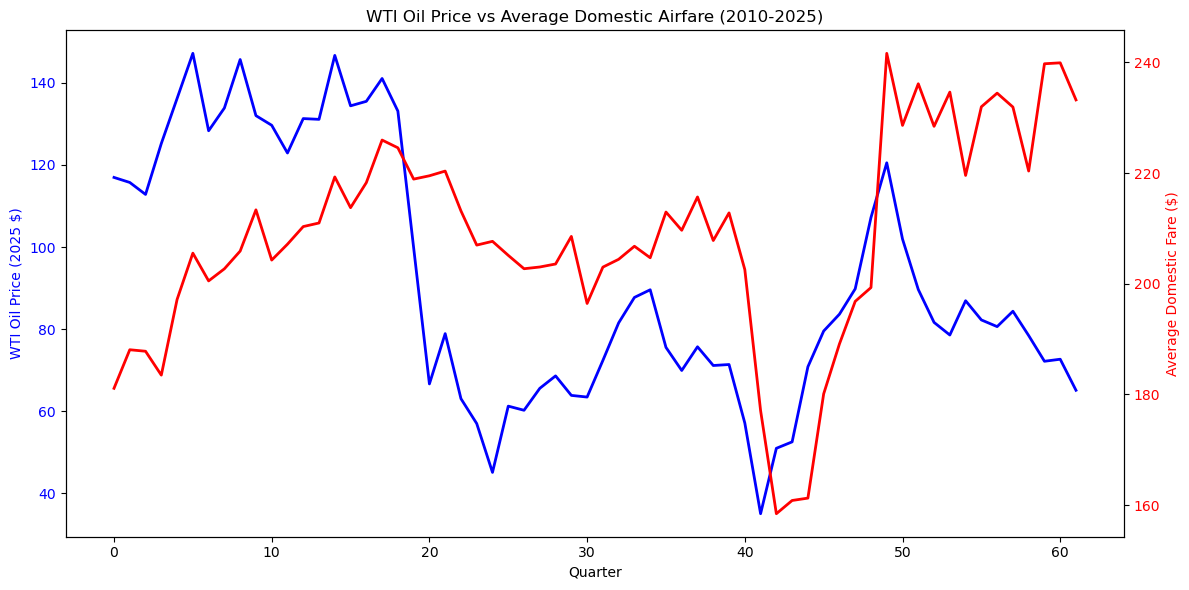

In [94]:
# Visualization 1: Line plot - Oil vs Airfare over time
print("Creating Visualization 1: Oil vs Airfare Time Series")

dataset_a_sorted = dataset_a.sort_values('quarter').reset_index(drop=True)

plt.figure(figsize=(12, 6))

# twinx() gives me two y-axes on same plot - need this bc oil prices and fares have diff scales
ax1 = plt.gca()
ax2 = ax1.twinx()

# plot oil price on left axis
ax1.plot(dataset_a_sorted.index, dataset_a_sorted['wti_real_2025'], 
         color='blue', linewidth=2, label='WTI Oil Price')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('WTI Oil Price (2025 $)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# plot airfare on right axis
ax2.plot(dataset_a_sorted.index, dataset_a_sorted['avg_domestic_fare'], 
         color='red', linewidth=2, label='Avg Domestic Fare')
ax2.set_ylabel('Average Domestic Fare ($)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('WTI Oil Price vs Average Domestic Airfare (2010-2025)')
plt.tight_layout()
plt.savefig('oil_vs_airfare_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualization 1 Explanation

This Dual-Axis Time Series Plot visualizes the relationship between WTI Oil Prices (Blue, Left Axis) and Average Domestic Airfares (Red, Right Axis) from 2010 to 2025. The trend shows that while Oil Prices are highly volatile with sharp spikes like from 2010-2014, airfares, however are mostly stable except for the large drop in 2020. This graph confirms that airfare prices are relatively sticky whereas oil prices are volatile. This means that either airlines are hedging against oil prices, accounting for oil price shocks in other ways, or keeping airfares based on other factors such as demand or competition. 

Creating Visualization 2: Oil vs Baggage Revenue Scatter


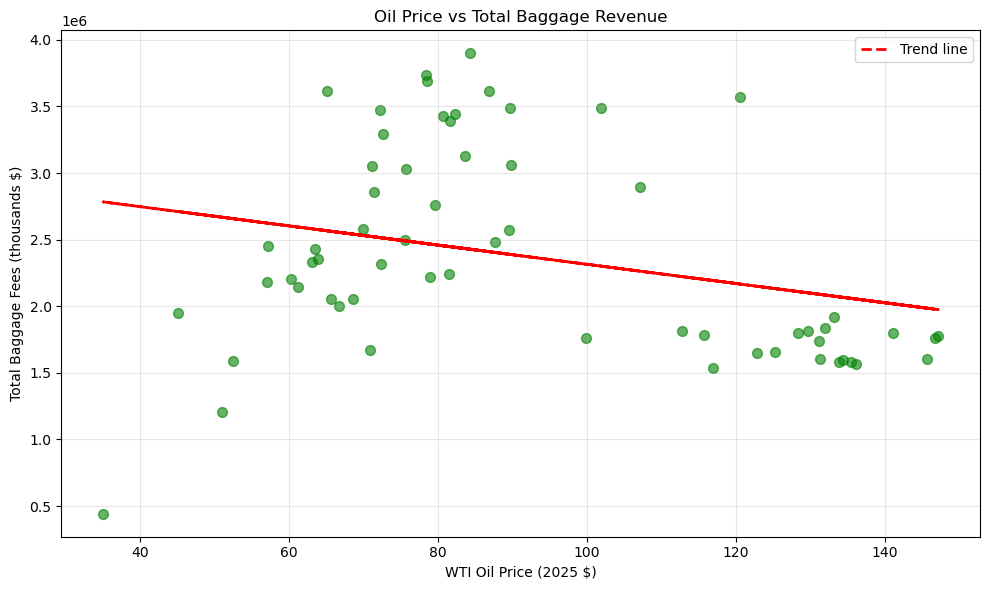

In [91]:
# Visualization 2: Scatter plot - Oil vs Baggage Revenue
print("Creating Visualization 2: Oil vs Baggage Revenue Scatter")

plt.figure(figsize=(10, 6))

plt.scatter(dataset_a['wti_real_2025'], dataset_a['total_baggage_fees'], 
            alpha=0.6, s=50, color='green')

# polyfit makes a trend line - just fits a line to the scatter points
z = np.polyfit(dataset_a['wti_real_2025'], dataset_a['total_baggage_fees'], 1)
p = np.poly1d(z)
plt.plot(dataset_a['wti_real_2025'], p(dataset_a['wti_real_2025']), 
         "r--", linewidth=2, label=f'Trend line')

plt.xlabel('WTI Oil Price (2025 $)')
plt.ylabel('Total Baggage Fees (thousands $)')
plt.title('Oil Price vs Total Baggage Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization 2 Explanation

This Scatter Plot with Polynomial Trendline visualizes the correlation between Real Oil Prices which is the x-axis and Total Baggage Fees which is the y-axis. The red dashed line represents the polynomial fit. The trend shows that as oil prices increase, baggage fees generally trend downward, but this is with significant variance. This is an interesting conclusion since it goes against what we found earlier. 

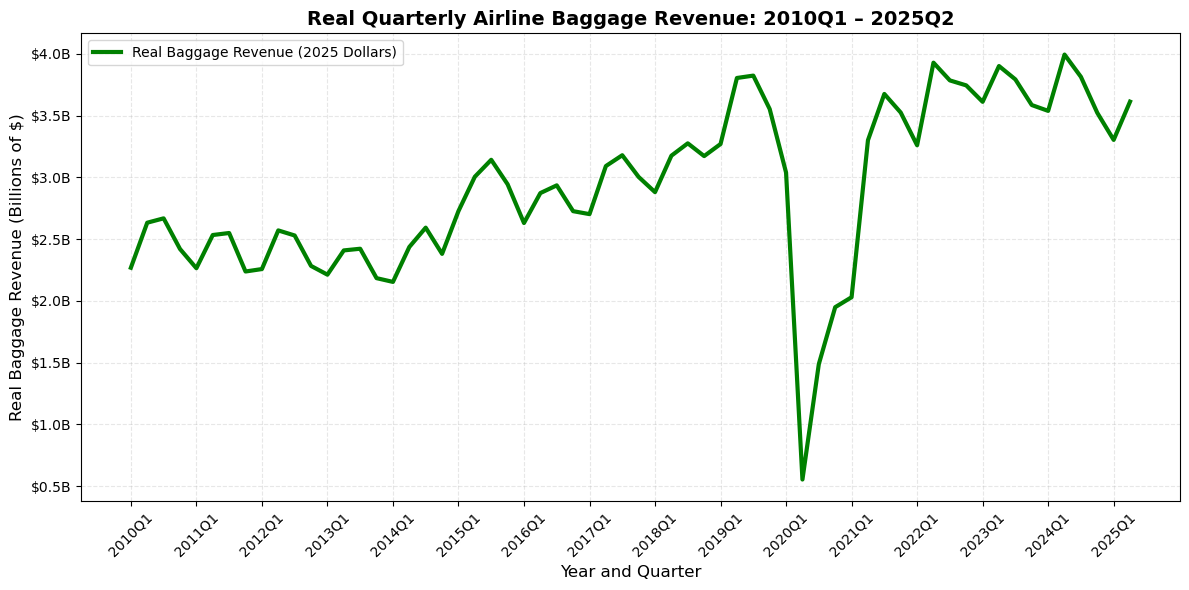

In [85]:
# Visualization
if 'dataset_a' in locals() and not dataset_a.empty:
    plt.figure(figsize=(12, 6))

    plt.plot(dataset_a['quarter'], dataset_a['revenue_billions'], 
             color='Green', linewidth=3, label='Real Baggage Revenue (2025 Dollars)')

    # Labels and Title
    plt.xlabel('Year and Quarter', fontsize=12)
    plt.ylabel('Real Baggage Revenue (Billions of $)', fontsize=12)

    start_q = dataset_a['quarter'].iloc[0]
    end_q = dataset_a['quarter'].iloc[-1]
    plt.title(f'Real Quarterly Airline Baggage Revenue: {start_q} – {end_q}', fontsize=14, fontweight='bold')

    # Format Y-Axis to show Billions
    plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.1f}B'))

    # Clean X-Axis (Show every 4th tick)
    plt.xticks(dataset_a['quarter'][::4], rotation=45)

    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='upper left')
    plt.tight_layout()

    # Show
    plt.show()

### Visualization 3 Explanation

This Line Chart tracks the total Real Baggage Revenue generated by airlines, adjusted for inflation to 2025 dollars. The graph shows a distinct upward trajectory from 2010 through 2025, illustrating the industry's increasing reliance on 'unbundled' revenue. The seasonality is also visible in the jagged peaks and valleys, correlating with high-travel quarters. There is also a severe outlier during 2020 however it looks like the airline industry has recovered from this. 

# Cited Sources

If you used any additional sources to complete your Data Analysis section, list them here:


*   Example Module Documentation
*   Example Stack Overflow Assistance

